# 03 - Baseline TF-IDF + Regresión Logística

## 1. Objetivo

Construir el baseline clásico de clasificación temática utilizando el corpus AG News preprocesado en la Entrega 2.

La representación del texto se realizará mediante TF-IDF y el modelo de clasificación será Regresión Logística. El vectorizador será ajustado exclusivamente sobre el conjunto de entrenamiento para evitar fuga de datos, mientras que el conjunto de prueba se utilizará únicamente para la evaluación final.

El desempeño se analizará mediante Precision, Recall, F1-Score y matriz de confusión.

## 2. Importación de librerías

In [1]:
# ==========================================
# Librerías generales
# ==========================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================
# Configuración del proyecto
# ==========================================

from src.paths import (
    PROJECT_ROOT,
    DATA_PROCESSED,
    OUTPUTS_FIGURES,
    OUTPUTS_TABLES,
)


# ==========================================
# Scikit-learn
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.metrics import accuracy_score

## 3. Carga del corpus preprocesado

Se reutilizan los conjuntos de entrenamiento y prueba generados durante la etapa de preprocesamiento. Ambos splits permanecen separados durante todo el pipeline: el conjunto de entrenamiento será utilizado para ajustar la representación TF-IDF y entrenar el clasificador, mientras que el conjunto de prueba se reservará exclusivamente para la evaluación final.

In [2]:
# ==========================================
# Rutas del corpus preprocesado
# ==========================================

train_path = DATA_PROCESSED / "ag_news_train_processed.csv"
test_path = DATA_PROCESSED / "ag_news_test_processed.csv"


# ==========================================
# Carga de datos
# ==========================================

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Registros de entrenamiento: {len(df_train)}")
print(f"Registros de prueba: {len(df_test)}")

print("\nColumnas disponibles:")
print(df_train.columns.tolist())

display(df_train.head())

Registros de entrenamiento: 8000
Registros de prueba: 2000

Columnas disponibles:
['text', 'label', 'num_words', 'text_processed']


,text,label,num_words,text_processed
0,"Red Hat Appoints New CFO. September 2, 2004 --...",Sci_Tech,30,red hat appoint new cfo september web host ind...
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",Sci_Tech,32,sprint sbc hotspot roam deal sprint sbc commun...
2,Radio Outage Grounds West Coast Flights. Airpo...,Business,31,radio outage ground west coast flights airport...
3,Hollywood lawsuits to strike Net pirates. Holl...,Sci_Tech,43,hollywood lawsuit strike net pirate hollywood ...
4,Custis Takes Control. Family and Tony Robbins ...,Sports,28,custis take control family tony robbin mature ...


## 4. Verificación del corpus de entrada

Antes de vectorizar, se verifica que los conjuntos de entrenamiento y prueba conserven las columnas esperadas, no presenten valores nulos en las variables necesarias y mantengan la distribución de clases heredada de la etapa anterior.

In [3]:
# ==========================================
# Verificación estructural
# ==========================================

columnas_requeridas = {"text_processed", "label"}

print("Columnas requeridas en train:",
      columnas_requeridas.issubset(df_train.columns))

print("Columnas requeridas en test:",
      columnas_requeridas.issubset(df_test.columns))


# ==========================================
# Valores nulos
# ==========================================

print("\nValores nulos en train:")
print(df_train[["text_processed", "label"]].isnull().sum())

print("\nValores nulos en test:")
print(df_test[["text_processed", "label"]].isnull().sum())


# ==========================================
# Distribución de clases
# ==========================================

print("\nDistribución de clases en train:")
print(df_train["label"].value_counts())

print("\nDistribución de clases en test:")
print(df_test["label"].value_counts())

Columnas requeridas en train: True
Columnas requeridas en test: True

Valores nulos en train:
text_processed    0
label             0
dtype: int64

Valores nulos en test:
text_processed    0
label             0
dtype: int64

Distribución de clases en train:
label
Sci_Tech    2000
Business    2000
Sports      2000
World       2000
Name: count, dtype: int64

Distribución de clases en test:
label
World       500
Business    500
Sports      500
Sci_Tech    500
Name: count, dtype: int64


## 5. Preparación de variables

Se separan las variables predictoras (`X`) y la variable objetivo (`y`). El modelo utilizará exclusivamente el texto preprocesado como entrada, mientras que la columna `label` será utilizada como variable objetivo para el entrenamiento y la evaluación.

In [4]:
# ==========================================
# Variables predictoras
# ==========================================

X_train = df_train["text_processed"]
X_test = df_test["text_processed"]


# ==========================================
# Variable objetivo
# ==========================================

y_train = df_train["label"]
y_test = df_test["label"]


# ==========================================
# Verificación
# ==========================================

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000,)
X_test : (2000,)
y_train: (8000,)
y_test : (2000,)


## 6. Selección de configuración TF-IDF

Para seleccionar la configuración del vectorizador sin utilizar el conjunto de prueba, se divide temporalmente el conjunto de entrenamiento en subconjuntos de entrenamiento y validación.

La partición se realiza de forma estratificada para conservar la distribución balanceada de las cuatro categorías. El conjunto de prueba oficial permanece completamente aislado durante esta etapa y se reserva exclusivamente para la evaluación final del baseline.

In [5]:
# ==========================================
# División interna train / validation
# ==========================================

X_train_dev, X_val, y_train_dev, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Train interno:", X_train_dev.shape)
print("Validación   :", X_val.shape)

print("\nDistribución de clases - train interno:")
print(y_train_dev.value_counts())

print("\nDistribución de clases - validación:")
print(y_val.value_counts())

Train interno: (6400,)
Validación   : (1600,)

Distribución de clases - train interno:
label
Sports      1600
Sci_Tech    1600
World       1600
Business    1600
Name: count, dtype: int64

Distribución de clases - validación:
label
World       400
Sports      400
Sci_Tech    400
Business    400
Name: count, dtype: int64


In [6]:
# ==========================================
# Definición de configuraciones
# ==========================================

configuraciones_tfidf = {
    "config_1": {
        "max_features": 5000,
        "ngram_range": (1, 1),
    },
    "config_2": {
        "max_features": 10000,
        "ngram_range": (1, 1),
    },
    "config_3": {
        "max_features": 10000,
        "ngram_range": (1, 2),
    },
}

for nombre, parametros in configuraciones_tfidf.items():
    print(nombre, parametros)

config_1 {'max_features': 5000, 'ngram_range': (1, 1)}
config_2 {'max_features': 10000, 'ngram_range': (1, 1)}
config_3 {'max_features': 10000, 'ngram_range': (1, 2)}


## 7. Evaluación de configuraciones TF-IDF

Cada configuración TF-IDF se ajusta exclusivamente sobre el conjunto de entrenamiento mediante `fit_transform()`. El conjunto de prueba se transforma posteriormente mediante `transform()`, utilizando el vocabulario y los pesos aprendidos a partir de entrenamiento.

Para comparar las configuraciones bajo las mismas condiciones, se entrena una Regresión Logística con cada representación y se registra su desempeño sobre el conjunto de prueba.

In [7]:
# ==========================================
# Comparación de configuraciones TF-IDF
# ==========================================

resultados_tfidf = []

for nombre, parametros in configuraciones_tfidf.items():

    # Crear vectorizador con la configuración actual
    vectorizador = TfidfVectorizer(**parametros)

    # Ajustar exclusivamente sobre train interno
    X_train_dev_tfidf = vectorizador.fit_transform(X_train_dev)

    # Transformar validación sin reajustar el vectorizador
    X_val_tfidf = vectorizador.transform(X_val)

    # Entrenar el mismo modelo para cada configuración
    modelo = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    modelo.fit(X_train_dev_tfidf, y_train_dev)

    # Evaluación sobre validación
    y_val_pred = modelo.predict(X_val_tfidf)

    accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    resultados_tfidf.append({
        "configuracion": nombre,
        "max_features": parametros["max_features"],
        "ngram_range": str(parametros["ngram_range"]),
        "n_features_reales": X_train_dev_tfidf.shape[1],
        "accuracy_val": accuracy,
    })


# ==========================================
# Resultados
# ==========================================

df_resultados_tfidf = pd.DataFrame(resultados_tfidf)

df_resultados_tfidf

,configuracion,max_features,ngram_range,n_features_reales,accuracy_val
0,config_1,5000,"(1, 1)",5000,0.890625
1,config_2,10000,"(1, 1)",10000,0.892500
2,config_3,10000,"(1, 2)",10000,0.891875


### Observación metodológica sobre la selección de configuración

Se compararon tres configuraciones de TF-IDF modificando `max_features` y `ngram_range`, manteniendo constante el clasificador de Regresión Logística.

La selección se realizó sobre un conjunto de validación separado del conjunto de entrenamiento oficial, preservando el conjunto de prueba exclusivamente para la evaluación final. El vectorizador fue ajustado mediante `fit_transform()` únicamente sobre el train interno y aplicado mediante `transform()` sobre validación.

La configuración con 10.000 características y unigramas (`ngram_range=(1, 1)`) obtuvo el mayor accuracy de validación (0,8925), superando levemente a la configuración que incorporó también bigramas (0,891875). En consecuencia, se adopta `config_2` como configuración definitiva del baseline.

## 8. Construcción del baseline definitivo

A partir de la experimentación previa se adopta la configuración TF-IDF con un máximo de 10.000 características y representación mediante unigramas.

El vectorizador definitivo se ajusta exclusivamente sobre el conjunto de entrenamiento. Posteriormente, la misma representación se utiliza para transformar el conjunto de prueba y entrenar el baseline oficial del proyecto mediante Regresión Logística.

In [8]:
# ==========================================
# Vectorizador TF-IDF definitivo
# ==========================================

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 1)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


# ==========================================
# Verificación de dimensiones
# ==========================================

print("Train TF-IDF:", X_train_tfidf.shape)
print("Test TF-IDF :", X_test_tfidf.shape)
print("Vocabulario:", len(tfidf.vocabulary_))

Train TF-IDF: (8000, 10000)
Test TF-IDF : (2000, 10000)
Vocabulario: 10000


In [9]:
# ==========================================
# Regresión Logística
# ==========================================

modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_logistico.fit(X_train_tfidf, y_train)

print("Entrenamiento finalizado.")

Entrenamiento finalizado.


In [10]:
# ==========================================
# Predicciones sobre test
# ==========================================

y_pred = modelo_logistico.predict(X_test_tfidf)

accuracy_final = accuracy_score(y_test, y_pred)

print(f"Accuracy del baseline: {accuracy_final:.4f}")

Accuracy del baseline: 0.8930


## 9. Evaluación del modelo

El desempeño del baseline se evalúa sobre el conjunto de prueba mediante Precision, Recall y F1-Score para cada categoría. Estas métricas permiten complementar el accuracy global y analizar si el comportamiento del clasificador es consistente entre las distintas clases del corpus.

In [11]:
# ==========================================
# Reporte de clasificación
# ==========================================

reporte = classification_report(
    y_test,
    y_pred,
    digits=4
)

print(reporte)

              precision    recall  f1-score   support

    Business     0.8428    0.8580    0.8503       500
    Sci_Tech     0.8745    0.8780    0.8762       500
      Sports     0.9487    0.9620    0.9553       500
       World     0.9066    0.8740    0.8900       500

    accuracy                         0.8930      2000
   macro avg     0.8932    0.8930    0.8930      2000
weighted avg     0.8932    0.8930    0.8930      2000



### Observación de resultados

El baseline alcanzó un accuracy global de 0,8930 y un F1-Score macro de 0,8930, mostrando un desempeño general elevado y relativamente consistente entre las cuatro categorías.

La categoría `Sports` presentó el mejor rendimiento, con un F1-Score de 0,9553, mientras que `Business` registró el menor desempeño, con un F1-Score de 0,8503. `Sci_Tech` y `World` alcanzaron valores intermedios de 0,8762 y 0,8900, respectivamente.

Los promedios macro y ponderado coinciden debido al balance del conjunto de prueba, compuesto por 500 documentos de cada categoría. La matriz de confusión permitirá analizar posteriormente entre qué clases se concentran los errores observados.

## 10. Matriz de confusión

La matriz de confusión permite analizar la distribución de los aciertos y errores del clasificador entre las cuatro categorías. Este análisis complementa las métricas agregadas y permite identificar qué clases presentan mayores dificultades de diferenciación.

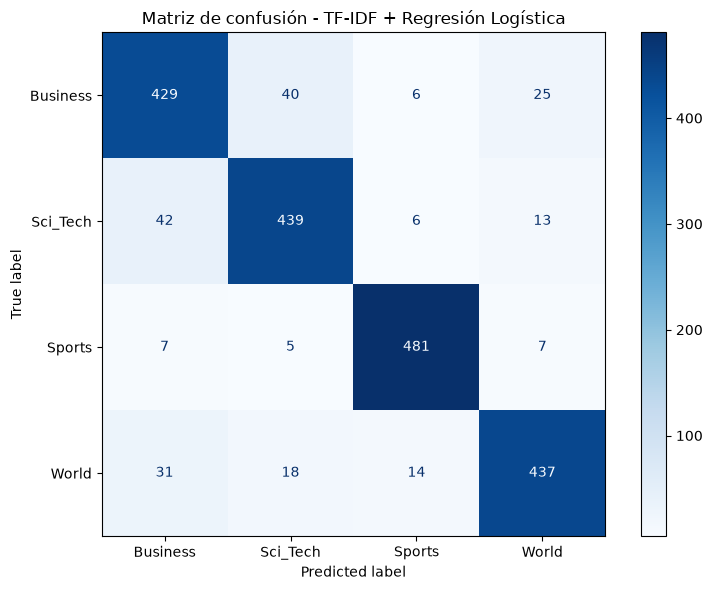

In [12]:
# ==========================================
# Matriz de confusión
# ==========================================

matriz_confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=modelo_logistico.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=modelo_logistico.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión - TF-IDF + Regresión Logística")
plt.tight_layout()

plt.show()

### Observación de la matriz de confusión

La matriz de confusión confirma que `Sports` es la categoría mejor diferenciada por el baseline, con 481 clasificaciones correctas sobre 500 documentos.

La principal dificultad se concentra entre `Business` y `Sci_Tech`: 40 documentos de `Business` fueron clasificados como `Sci_Tech`, mientras que 42 documentos de `Sci_Tech` fueron clasificados como `Business`. También se observa cierta confusión entre `World` y `Business`, aunque de menor magnitud.

Estos resultados son consistentes con las métricas obtenidas previamente: `Business` presenta el menor F1-Score, mientras que `Sports` alcanza el mejor desempeño. La matriz permite localizar los errores y muestra que las dificultades del modelo no se distribuyen uniformemente entre las categorías.

## 11. Persistencia de resultados

Se persisten los resultados necesarios para la comparación posterior entre el baseline clásico y el modelo Transformer en el Notebook 05.

La persistencia se limita a los artefactos requeridos para dar continuidad al flujo del proyecto. El modelo de Regresión Logística y el vectorizador TF-IDF no se serializan, ya que las ramas correspondientes a los Notebooks 03 y 04 son independientes y el Notebook 05 consume sus resultados de evaluación, no los modelos entrenados.

### 11.1 Figura de la matriz de confusión

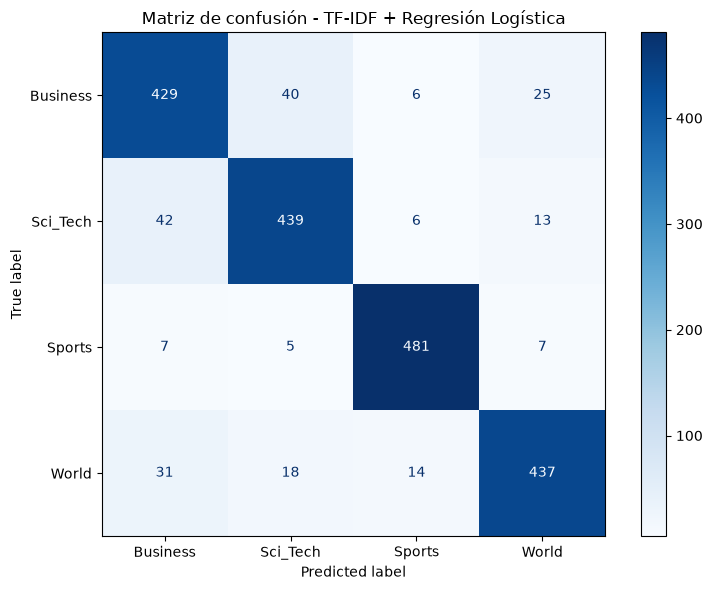

In [13]:
# ==========================================
# Matriz de confusión
# ==========================================

matriz_confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=modelo_logistico.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=modelo_logistico.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión - TF-IDF + Regresión Logística")
plt.tight_layout()

fig.savefig(
    OUTPUTS_FIGURES / "matriz_confusion_tfidf_logistica.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 11.2 Métricas estructuradas

In [14]:
# ==========================================
# Métricas del baseline
# ==========================================

reporte_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

df_metricas_baseline = pd.DataFrame(reporte_dict).transpose()

df_metricas_baseline

,precision,recall,f1-score,support
Business,0.842829,0.858,0.850347,500.000
Sci_Tech,0.874502,0.878,0.876248,500.000
Sports,0.948718,0.962,0.955313,500.000
World,0.906639,0.874,0.890020,500.000
accuracy,0.893000,0.893,0.893000,0.893
macro avg,0.893172,0.893,0.892982,2000.000
weighted avg,0.893172,0.893,0.892982,2000.000


In [15]:
# ==========================================
# Persistencia de métricas
# ==========================================

metricas_path = OUTPUTS_TABLES / "metricas_baseline_tfidf_logistica.csv"

df_metricas_baseline.to_csv(
    metricas_path,
    index=True
)

print("Métricas guardadas en:")
print(metricas_path)

Métricas guardadas en:
C:\proyecto_nlp_ds3\proyecto_nlp_ds3\outputs\tables\metricas_baseline_tfidf_logistica.csv


## 12. Conclusiones

Se construyó un baseline clásico de clasificación temática utilizando TF-IDF como representación vectorial y Regresión Logística como clasificador. La comparación de configuraciones se realizó sobre un conjunto de validación separado del entrenamiento, preservando el conjunto de prueba para la evaluación final. La configuración seleccionada utilizó un máximo de 10.000 características y unigramas, alcanzando un accuracy final de 0,8930 sobre test.

El análisis por categoría mostró diferencias en el desempeño. `Sports` presentó el mejor resultado, con un F1-Score de 0,9553, mientras que `Business` obtuvo el menor, con 0,8503. La matriz de confusión identificó que la principal dificultad del modelo se concentra en la diferenciación entre `Business` y `Sci_Tech`.

En conjunto, el baseline presenta un desempeño sólido sobre las cuatro categorías de AG News. Sus métricas fueron persistidas como artefactos estructurados para permitir su comparación posterior con los resultados de la rama Transformer en el Notebook 05.